# E40 — O canal com orçamento

Dois observadores, um por perna, cada um com o seu canal: só a fração declarada dos dias atravessa.
Quanto da proteção conjunta sobrevive quando observar custa.

In [1]:
import sys
sys.path.insert(0, "lib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from frevolab import dados, graficos, protecao

SEMENTE = 107          # <- brinque com:
JANELA = 252
CAUDA = 0.05
PESOS = (0.5, 0.5)
NIVEL = 0.05
FRACOES = (1.0, 0.5, 0.2, 0.1)
NOMES_F = {1.0: "inteiro", 0.5: "meio", 0.2: "quinto", 0.1: "decimo"}
SORTES = 200

retornos_sp = dados.carregar_serie("sp500.csv").pct_change().dropna()
retornos_ib = dados.carregar_serie("ibov.csv").pct_change().dropna()
print("sp %d | ibov %d dias" % (retornos_sp.size, retornos_ib.size))

sp 6718 | ibov 6620 dias


In [2]:
# O controle embutido: a fracao cheia devolve o capitulo.
cheio = protecao.canal(retornos_sp, retornos_ib, 1.0, janela=JANELA, cauda=CAUDA, pesos=PESOS,
                       nivel=NIVEL, semente=SEMENTE)
print("fracao 1.0 | verdadeiros %d | detectados %d | recall %.3f | capital conjunto %.4f" % (
    cheio["verdadeiros"], cheio["detectados"], cheio["recall"], cheio["capital_conjunto"]))

fracao 1.0 | verdadeiros 113 | detectados 113 | recall 1.000 | capital conjunto 0.0792


In [3]:
# A degradacao contra a fracao, com a incerteza ENTRE sortes do canal.
curva = {}
for f in FRACOES:
    det, rec, cap, des = [], [], [], []
    for i in range(SORTES):
        r = protecao.canal(retornos_sp, retornos_ib, f, janela=JANELA, cauda=CAUDA, pesos=PESOS,
                           nivel=NIVEL, semente=SEMENTE + 1000 + i)
        det.append(r["detectados"])
        rec.append(r["recall"])
        if r["detectados"] >= 4 and r["capital_conjunto"] == r["capital_conjunto"]:
            cap.append(r["capital_conjunto"])
            des.append(r["descoberto"])
    q = lambda v: (float(np.quantile(v, 0.025)), float(np.quantile(v, 0.5)), float(np.quantile(v, 0.975)))
    curva[f] = {"detectados": q(det), "recall": q(rec),
                "calibraveis": len(cap) / float(SORTES),
                "capital": q(cap) if len(cap) >= 2 else None,
                "descoberto": q(des) if len(des) >= 2 else None}
    prev = f * f * cheio["verdadeiros"]
    cap_txt = "capital %.4f" % curva[f]["capital"][1] if curva[f]["capital"] else "sem capital calibravel"
    print("f %.1f | detectados %5.1f [%3d; %3d] | recall %.3f [%.3f; %.3f] | calibraveis %.2f | %s | previsto f2 %.1f" % (
        f, curva[f]["detectados"][1], curva[f]["detectados"][0], curva[f]["detectados"][2],
        curva[f]["recall"][1], curva[f]["recall"][0], curva[f]["recall"][2],
        curva[f]["calibraveis"], cap_txt, prev))

f 1.0 | detectados 113.0 [113; 113] | recall 1.000 [1.000; 1.000] | calibraveis 1.00 | capital 0.0792 | previsto f2 113.0


f 0.5 | detectados  27.0 [ 18;  36] | recall 0.186 [0.133; 0.265] | calibraveis 1.00 | capital 0.0725 | previsto f2 28.2


f 0.2 | detectados   4.0 [  1;   8] | recall 0.027 [0.000; 0.053] | calibraveis 0.57 | capital 0.0536 | previsto f2 4.5


f 0.1 | detectados   0.0 [  0;   2] | recall 0.000 [0.000; 0.018] | calibraveis 0.01 | sem capital calibravel | previsto f2 1.1


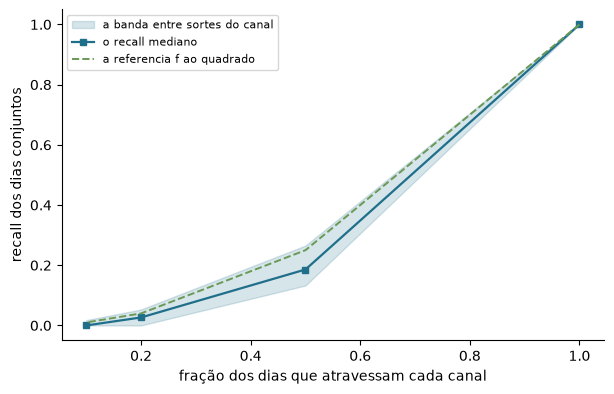

In [4]:
# Figura 1: o recall dos dias conjuntos contra a fracao, com a banda entre sortes e o f2 de referencia.
xs = np.array([f for f in FRACOES])
rec_med = np.array([curva[f]["recall"][1] for f in FRACOES])
rec_min = np.array([curva[f]["recall"][0] for f in FRACOES])
rec_max = np.array([curva[f]["recall"][2] for f in FRACOES])
fig, ax = plt.subplots(figsize=(7.0, 4.3))
ax.fill_between(xs, rec_min, rec_max, color="#1f6f8b", alpha=0.18, label="a banda entre sortes do canal")
ax.plot(xs, rec_med, "s-", color="#1f6f8b", lw=1.6, ms=5, label="o recall mediano")
ax.plot(xs, xs * xs, "--", color="#6a9955", lw=1.4, label="a referencia f ao quadrado")
ax.set_xlabel("fração dos dias que atravessam cada canal")
ax.set_ylabel("recall dos dias conjuntos")
ax.legend(fontsize=8, loc="best")
ax.spines[["top", "right"]].set_visible(False)
graficos.salvar(fig, "E40_canal", 1)
plt.show()

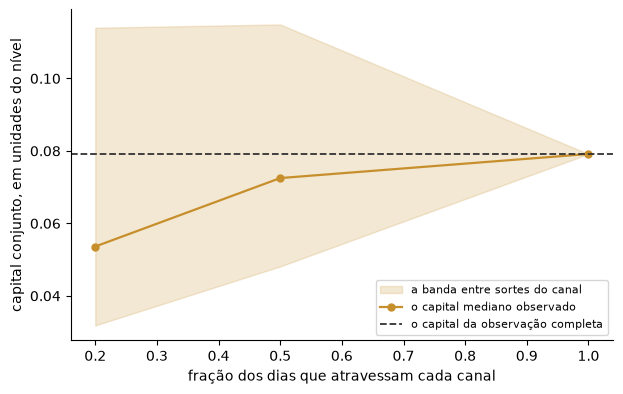

In [5]:
# Figura 2: o capital conjunto observado contra a fracao, com a linha da observacao completa.
com_cap = [f for f in FRACOES if curva[f]["capital"]]
xs_cap = np.array(com_cap)
cap_med = np.array([curva[f]["capital"][1] for f in com_cap])
cap_min = np.array([curva[f]["capital"][0] for f in com_cap])
cap_max = np.array([curva[f]["capital"][2] for f in com_cap])
fig, ax = plt.subplots(figsize=(7.0, 4.3))
ax.fill_between(xs_cap, cap_min, cap_max, color="#c78f2c", alpha=0.20, label="a banda entre sortes do canal")
ax.plot(xs_cap, cap_med, "o-", color="#c78f2c", lw=1.6, ms=5, label="o capital mediano observado")
ax.axhline(cheio["capital_conjunto"], color="#333333", ls="--", lw=1.3,
           label="o capital da observação completa")
ax.set_xlabel("fração dos dias que atravessam cada canal")
ax.set_ylabel("capital conjunto, em unidades do nível")
ax.legend(fontsize=8, loc="best")
ax.spines[["top", "right"]].set_visible(False)
graficos.salvar(fig, "E40_canal", 2)
plt.show()

In [6]:
# Leitura visual das figuras (declaratória, contra o PNG):
# 1) a curva do recall mediano cresce com a fração e fica ABAIXO da tracejada do quadrado em toda a
#    faixa; a banda entre sortes é larga na metade e estreita nas pontas;
# 2) o capital tem pontos só na fração cheia, na metade e no quinto; a banda da metade engola a
#    linha da observação completa; o ponto do quinto fica abaixo, com banda larga.

In [7]:
# O que sai do laboratório e o que o livro cita.
resultado = {"canal_verdadeiros": int(cheio["verdadeiros"]),
             "canal_inteiro_detectados": int(cheio["detectados"]),
             "canal_inteiro_capital": round(cheio["capital_conjunto"], 4),
             "canal_inteiro_recall": round(cheio["recall"], 4)}
for f in FRACOES[1:]:
    n = NOMES_F[f]
    resultado["canal_%s_detectados" % n] = round(curva[f]["detectados"][1], 1)
    resultado["canal_%s_detectados_min" % n] = int(curva[f]["detectados"][0])
    resultado["canal_%s_detectados_max" % n] = int(curva[f]["detectados"][2])
    resultado["canal_%s_recall" % n] = round(curva[f]["recall"][1], 3)
    resultado["canal_%s_recall_min" % n] = round(curva[f]["recall"][0], 3)
    resultado["canal_%s_recall_max" % n] = round(curva[f]["recall"][2], 3)
    resultado["canal_%s_calibraveis" % n] = round(curva[f]["calibraveis"], 3)
    if curva[f]["capital"]:
        resultado["canal_%s_capital" % n] = round(curva[f]["capital"][1], 4)
        resultado["canal_%s_capital_min" % n] = round(curva[f]["capital"][0], 4)
        resultado["canal_%s_capital_max" % n] = round(curva[f]["capital"][2], 4)
        resultado["canal_%s_descoberto" % n] = round(curva[f]["descoberto"][1], 3)

import json
from pathlib import Path
caminho = Path("lab/resultados/E40_canal.json")
caminho.write_text(json.dumps(resultado, indent=1, ensure_ascii=False, sort_keys=True), encoding="utf-8")
print(json.dumps(resultado, ensure_ascii=False, indent=1, sort_keys=True))

{
 "canal_decimo_calibraveis": 0.005,
 "canal_decimo_detectados": 0.0,
 "canal_decimo_detectados_max": 2,
 "canal_decimo_detectados_min": 0,
 "canal_decimo_recall": 0.0,
 "canal_decimo_recall_max": 0.018,
 "canal_decimo_recall_min": 0.0,
 "canal_inteiro_capital": 0.0792,
 "canal_inteiro_detectados": 113,
 "canal_inteiro_recall": 1.0,
 "canal_meio_calibraveis": 1.0,
 "canal_meio_capital": 0.0725,
 "canal_meio_capital_max": 0.1149,
 "canal_meio_capital_min": 0.0481,
 "canal_meio_descoberto": 0.455,
 "canal_meio_detectados": 27.0,
 "canal_meio_detectados_max": 36,
 "canal_meio_detectados_min": 18,
 "canal_meio_recall": 0.186,
 "canal_meio_recall_max": 0.265,
 "canal_meio_recall_min": 0.133,
 "canal_quinto_calibraveis": 0.575,
 "canal_quinto_capital": 0.0536,
 "canal_quinto_capital_max": 0.114,
 "canal_quinto_capital_min": 0.0318,
 "canal_quinto_descoberto": 0.428,
 "canal_quinto_detectados": 4.0,
 "canal_quinto_detectados_max": 8,
 "canal_quinto_detectados_min": 1,
 "canal_quinto_recall":